In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import (
    load_digits, make_swiss_roll, make_moons, make_blobs
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from umap import UMAP
from time import time

np.random.seed(42)

# Utility for consistent coloured scatter plots
def scatter2d(ax, X, y, title="", cmap="tab10", s=10, alpha=0.7):
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, s=s, alpha=alpha)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

/opt/anaconda3/envs/graph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


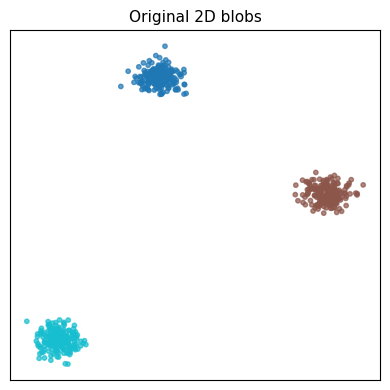

In [2]:
# ── 1.1  Generate three-cluster data ──
X_blobs, y_blobs = make_blobs(
    n_samples=600, centers=3, cluster_std=0.5, random_state=42
)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
scatter2d(ax, X_blobs, y_blobs, "Original 2D blobs")
plt.tight_layout(); plt.show()


/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


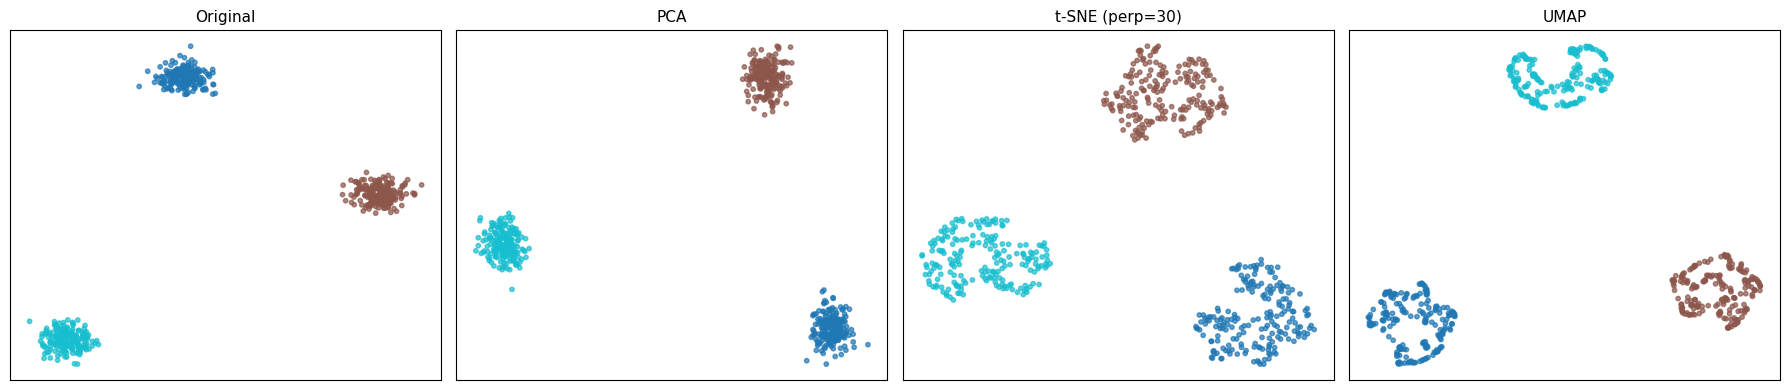

In [ ]:
# 1.2  Embed into 2D with PCA, t-SNE, UMAP
X_pca   = PCA(n_components=2).fit_transform(X_blobs)
X_tsne  = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_blobs)
X_umap  = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_blobs)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
scatter2d(axes[0], X_blobs, y_blobs, "Original")
scatter2d(axes[1], X_pca,   y_blobs, "PCA")
scatter2d(axes[2], X_tsne,  y_blobs, "t-SNE (perp=30)")
scatter2d(axes[3], X_umap,  y_blobs, "UMAP")
plt.tight_layout()
plt.show()


Observations
- PCA: the plot is essentially identical to the original (up to rotation/
  reflection). PCA is a linear projection; since the data is already 2D,
  there is nothing to reduce — it just finds the principal axes.
- t-SNE: the three clusters are clearly separated, but their RELATIVE
  distances may differ from the original. Cluster shapes may appear more
  uniform (rounder, similar sizes) than they really are.
- UMAP: similar to t-SNE — clusters are separated but relative distances
  and shapes may be distorted.

/opt/anaconda3/envs/graph/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


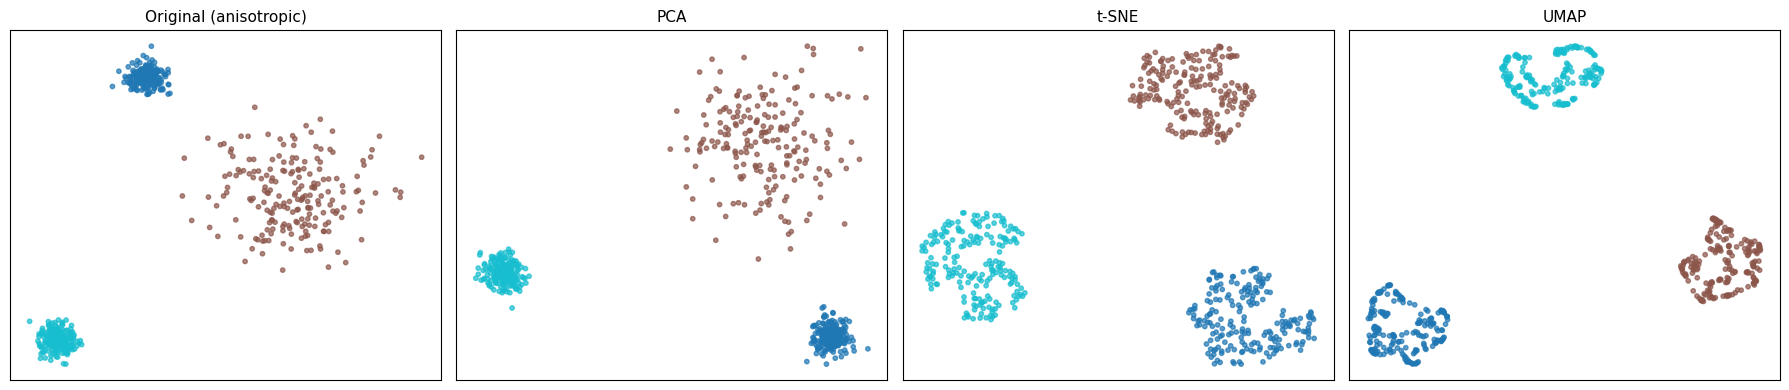

In [7]:
# ── 1.4  Anisotropic clusters ──
X_aniso, y_aniso = make_blobs(
    n_samples=600, centers=3, cluster_std=[0.5, 2.0, 0.5], random_state=42
)

X_pca_a  = PCA(n_components=2).fit_transform(X_aniso)
X_tsne_a = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_aniso)
X_umap_a = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_aniso)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
scatter2d(axes[0], X_aniso,  y_aniso, "Original (anisotropic)")
scatter2d(axes[1], X_pca_a,  y_aniso, "PCA")
scatter2d(axes[2], X_tsne_a, y_aniso, "t-SNE")
scatter2d(axes[3], X_umap_a, y_aniso, "UMAP")
plt.tight_layout(); plt.show()


- PCA preserves the spread difference perfectly: the large cluster
  visually occupies more area.
- t-SNE tends to EQUALISE cluster sizes. The adaptive sigma_i means
  that points in the spread-out cluster get larger bandwidths, making
  their local probabilities similar to those in tight clusters. The
  result is that the large cluster appears shrunk.
- UMAP behaves similarly to t-SNE: the spread difference is reduced
  (though UMAP sometimes preserves it slightly better than t-SNE).

Conclustion: cluster sizes in t-SNE/UMAP plots are NOT reliable indicators of true spread.